In [48]:
# --- Inputs: set once per recording/sorting run --- M2
raw_data_folder = r"C:\\SGL_DATA\\20260707_LGN_exp_g0\\20260707_LGN_exp_g0_imec0"
sorter_output_path = r"kilosort4_imec_ap_20260707_LGN_exp_job47328234\\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260707_LGN_exp_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [1]:
# --- Inputs: set once per recording/sorting run --- M1
raw_data_folder = r"C:\\SGL_DATA\\20260625_exp1_g0\\20260625_exp1_g0_imec0"
sorter_output_path = r"kilosort4_imec_ap_20260625_exp1_g0_job46233787\\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260625_exp1_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [1]:
# --- Inputs: set once per recording/sorting run --- M2-V1
raw_data_folder = r"C:\\SGL_DATA\\20260709_V1_exp_g0\\20260709_V1_exp_g0_imec0"
sorter_output_path = r"kilosort4_imec_ap_20260709_V1_exp_job47457293\\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260709_V1_exp_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


In [3]:
# Load the raw SpikeGLX recording (extracts metadata automatically)
recording = se.read_spikeglx(folder_path=raw_data_folder, stream_id="imec0.ap")

# Load the Kilosort sorting output directly
sorting = se.read_kilosort(folder_path=sorter_output_path)

# Register the recording with the sorting to enable time-based operations.
# Note: SortingExtractor has no `set_recording` method - the correct API is `register_recording`.
sorting.register_recording(recording)

# Get the exact sampling frequency directly from the .meta file
sampling_frequency = recording.get_sampling_frequency()
print(f"Successfully linked! Sampling frequency from .meta: {sampling_frequency} Hz")

# SpikeGLX times spikes from acquisition start, not from when recording/gate was
# enabled. The gap between the two is `firstSample` (samples) in the .meta file,
# which spikeinterface already folds into recording.get_start_time(). Subtract it
# so spike times are zeroed to when recording was actually enabled.
recording_start_offset_s = recording.get_start_time()
print(f"Recording start offset (acquisition start -> recording enabled): {recording_start_offset_s:.6f} s")

# Outputs go one directory up from the Kilosort sorter output folder
export_dir = os.path.dirname(sorter_output_path)

# --- Quality labels: curated cluster_group.tsv if it exists, else Kilosort's own cluster_KSLabel.tsv ---
labels_path = os.path.join(sorter_output_path, "cluster_group.tsv")
if not os.path.exists(labels_path):
    labels_path = os.path.join(sorter_output_path, "cluster_KSLabel.tsv")
labels_df = pd.read_csv(labels_path, sep="\t")
label_col = "group" if "group" in labels_df.columns else "KSLabel"
unit_quality = dict(zip(labels_df["cluster_id"], labels_df[label_col]))

# --- Peak channel per unit, from the Kilosort templates ---
templates = np.load(os.path.join(sorter_output_path, "templates.npy"))
peak_channel = {
    unit_id: int(np.argmax(np.max(np.abs(templates[unit_id]), axis=0)))
    for unit_id in sorting.get_unit_ids()
}

unit_ids = sorting.get_unit_ids()

# --- Spike times per unit, organized by unit, zeroed to recording-enabled time ---
spike_trains = {
    unit_id: np.sort(sorting.get_unit_spike_train(unit_id, return_times=True)) - recording_start_offset_s
    for unit_id in unit_ids
}
print(f"Total spikes: {sum(t.size for t in spike_trains.values())}, units: {sorting.get_num_units()}")

# --- Per-unit record: actual spike timestamps (not binned) plus qc label and channel. ---
# Units have different spike counts, so this is a dict/list rather than a rectangular
# numpy array - each unit's "row" is its own variable-length array of spike times (s).
unit_data = {
    unit_id: {
        "spike_times_s": spike_trains[unit_id],
        "quality_label": unit_quality.get(unit_id, "unknown"),
        "channel": peak_channel.get(unit_id, -1),
    }
    for unit_id in unit_ids
}

unit_data_path = os.path.join(export_dir, "unit_spike_data.pkl")
with open(unit_data_path, "wb") as f:
    pickle.dump(unit_data, f)
print(f"Saved per-unit spike data to: {unit_data_path}")

Successfully linked! Sampling frequency from .meta: 30000.0 Hz
Recording start offset (acquisition start -> recording enabled): 3413.208433 s
Total spikes: 3193562, units: 324
Saved per-unit spike data to: kilosort4_imec_ap_20260709_V1_exp_job47457293\unit_spike_data.pkl


`unit_spike_data.pkl` schema

Loading: `unit_data = pickle.load(open("unit_spike_data.pkl", "rb"))`

`unit_data` is a `dict` keyed by `unit_id` (int). Each value is itself a `dict` with:

| Key | Type | Meaning |
| --- | --- | --- |
| `spike_times_s` | `np.ndarray[float]`, variable length per unit | Sorted spike timestamps in seconds, relative to recording start |
| `quality_label` | `str` | Kilosort/curated QC label (e.g. `"good"`, `"mua"`, `"noise"`, `"unknown"`) |
| `channel` | `int` | Peak (max-amplitude) channel index for that unit |

Example: `unit_data[123]["spike_times_s"]` -> spike times for unit 123; `unit_data[123]["channel"]` -> its peak channel.


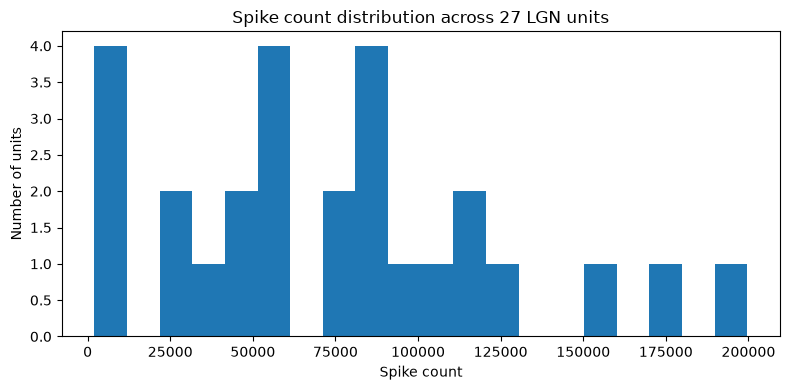

In [50]:
# select all the LGN units (label "good") for downstream analysis
unit_data = pickle.load(open("kilosort4_imec_ap_20260707_LGN_exp_job47328234\\unit_spike_data.pkl", "rb"))
# unit_data = pickle.load(open("kilosort4_imec_ap_20260625_exp1_job46233787\\unit_spike_data.pkl", "rb"))
# unit_data = pickle.load(open("kilosort4_imec_ap_20260709_V1_exp_job47457293\\unit_spike_data.pkl", "rb"))
lgn_channel_range = range(0, 55)  # inclusive LGN channel range
lgn_units = [
    unit_id
    for unit_id, record in unit_data.items()
    if record["quality_label"] == "good" and record["channel"] in lgn_channel_range
]
# unwanted_units = [22, 48]
# lgn_units = [unit_id for unit_id in lgn_units if unit_id not in unwanted_units]
# lgn_units = [27, 30, 31, 32, 33]
lgn_units = [unit_id for unit_id in lgn_units if unit_data[unit_id]["spike_times_s"].size < 200000]  # filter out units with too many spikes

spike_counts = [unit_data[unit_id]["spike_times_s"].size for unit_id in lgn_units]
plt.figure(figsize=(8, 4))
plt.hist(spike_counts, bins=20)
plt.xlabel("Spike count")
plt.ylabel("Number of units")
plt.title(f"Spike count distribution across {len(lgn_units)} LGN units")
plt.tight_layout()
plt.show()


In [ ]:
# raster plotting function for LGN units, optionally aligned to chirp onset detected in BNC channel
lgn_spike_times = {
    unit_id: unit_data[unit_id]["spike_times_s"]
    for unit_id in lgn_units
}
print(f"Selected {len(lgn_units)} good LGN units for downstream analysis")

def _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, t0, t1):
    start_frame = max(0, int(t0 * nidq_fs))
    end_frame = min(nidq_recording.get_num_samples(), int(t1 * nidq_fs))
    trace = nidq_recording.get_traces(
        channel_ids=[bnc_channel_id], start_frame=start_frame, end_frame=end_frame
    ).flatten()
    time = np.arange(start_frame, end_frame) / nidq_fs
    return time, trace

def _detect_chirp_onsets(time, trace, threshold, min_isi_s):
    thr = threshold if threshold is not None else (trace.max().astype(float) + trace.min()) / 2
    above = trace > thr
    rising_edges = np.flatnonzero(~above[:-1] & above[1:]) + 1
    onsets = time[rising_edges]
    if onsets.size:
        keep = np.diff(onsets, prepend=-np.inf) > min_isi_s
        onsets = onsets[keep]
    return onsets

def plot_raster(start_time_s, lapse_s, spike_times=None, bnc_channel=0, chirp_threshold=None,
                 min_isi_s=30.0, align_to_chirp=True, align_offset_s=0.5):
    if spike_times is None:
        spike_times = lgn_spike_times

    show_bnc = bool(nidq_file_path)
    nidq_recording = nidq_fs = bnc_channel_id = None
    if show_bnc:
        nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
        nidq_fs = nidq_recording.get_sampling_frequency()
        bnc_channel_id = nidq_recording.channel_ids[bnc_channel]

        if align_to_chirp:
            # nidq is zeroed to its own recording-enabled offset the same way imec is
            # (see recording_start_offset_s above), so start_time_s/end_time_s already
            # line up with the spike raster without any extra shift.
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, start_time_s, start_time_s + lapse_s
            )
            onset_candidates = _detect_chirp_onsets(search_time, search_trace, chirp_threshold, min_isi_s)
            if onset_candidates.size:
                start_time_s = onset_candidates[0] - align_offset_s
                print(f"Detected chirp onset at {onset_candidates[0]:.4f}s -> "
                      f"re-centered window to start at {start_time_s:.4f}s")

    end_time_s = start_time_s + lapse_s

    if show_bnc:
        fig, (bnc_ax, raster_ax) = plt.subplots(
            2, 1, sharex=True, figsize=(12, 0.3 * len(spike_times) + 3),
            gridspec_kw={"height_ratios": [1, 4]},
        )
    else:
        fig, raster_ax = plt.subplots(figsize=(12, 0.3 * len(spike_times) + 1))

    for row, (unit_id, times) in enumerate(spike_times.items()):
        window = times[(times >= start_time_s) & (times < end_time_s)]
        raster_ax.vlines(window, row, row + 0.8)
    raster_ax.set_yticks(np.arange(len(spike_times)) + 0.4)
    raster_ax.set_yticklabels([
        f"{unit_id} (ch{unit_data[unit_id]['channel']})" for unit_id in spike_times.keys()
    ])
    raster_ax.set_xlim(start_time_s, end_time_s)
    raster_ax.set_xlabel("Time (s)")
    raster_ax.set_ylabel("Unit ID (channel)")

    chirp_onset_times_s = np.array([])
    if show_bnc:
        bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, start_time_s, end_time_s)
        bnc_ax.plot(bnc_time, bnc_trace)
        bnc_ax.set_ylabel(f"BNC ({bnc_channel_id})")

        chirp_onset_times_s = _detect_chirp_onsets(bnc_time, bnc_trace, chirp_threshold, min_isi_s)
        for t in chirp_onset_times_s:
            bnc_ax.axvline(t, color="red", linestyle="--", alpha=0.6)
            raster_ax.axvline(t, color="red", linestyle="--", alpha=0.6)
        print(f"Detected {chirp_onset_times_s.size} chirp onset(s) in window: {chirp_onset_times_s}")

    fig.suptitle(f"Raster: {start_time_s:.2f}-{end_time_s:.2f} s")
    plt.tight_layout()
    plt.show()
    return fig, raster_ax, chirp_onset_times_s

# Example: fig, ax, chirp_onsets = plot_raster(start_time_s=10.0, lapse_s=2.0)

Selected 27 good LGN units for downstream analysis


Detected chirp onset at 3201.0482s -> re-centered window to start at 3200.5482s
Detected 1 chirp onset(s) in window: [3201.04820245]


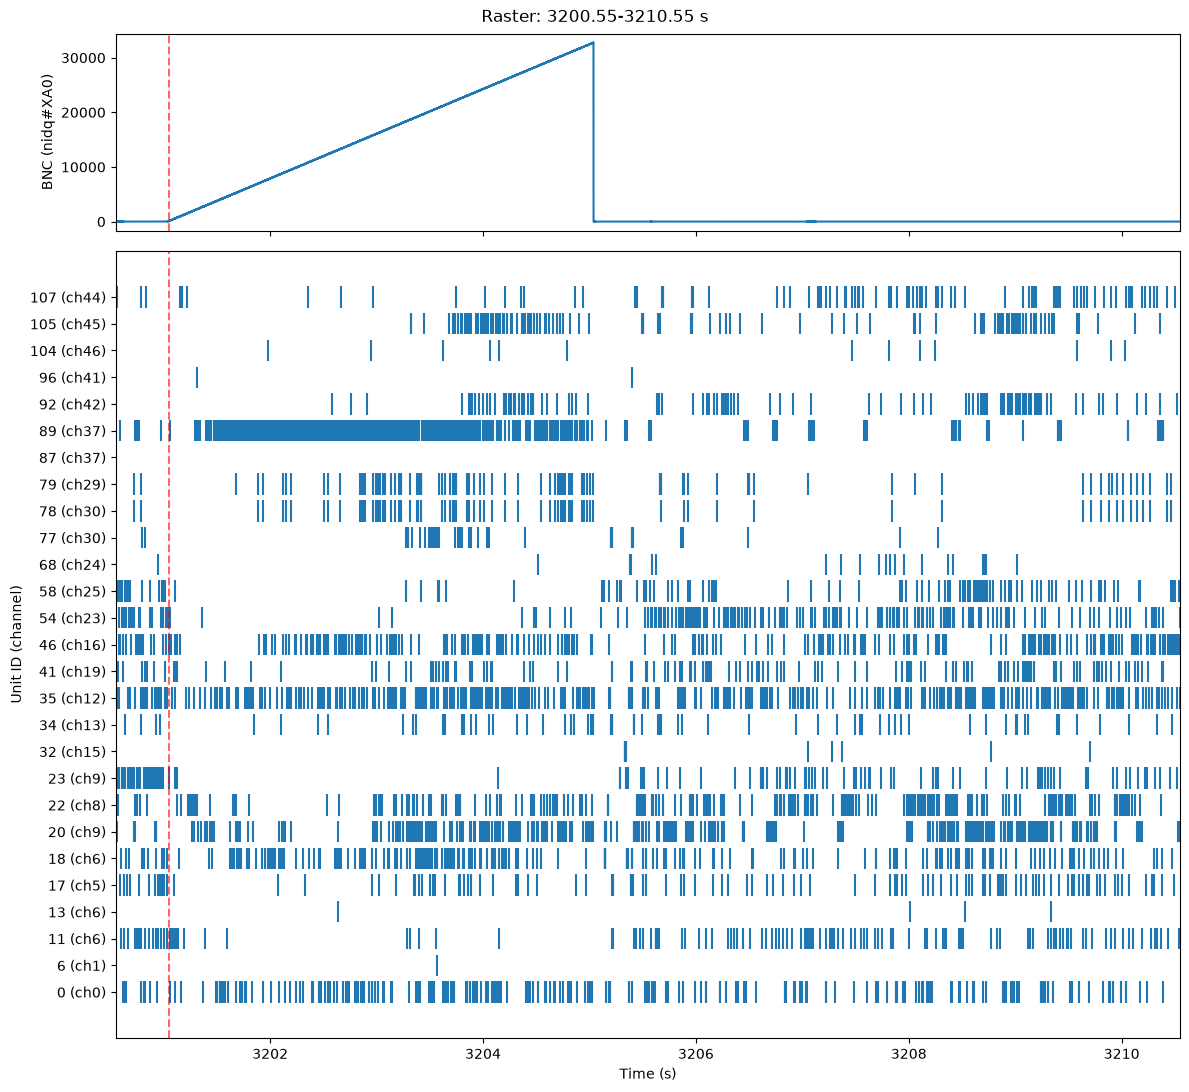

In [115]:
# plot selected raster window for LGN units, optionally aligned to chirp onset detected in BNC channel
k = 0
fig, ax, chirp_onsets = plot_raster(start_time_s=3003.5 + 65.5*3, lapse_s=10.0, chirp_threshold=100)

Selected 1 ramp units for downstream analysis


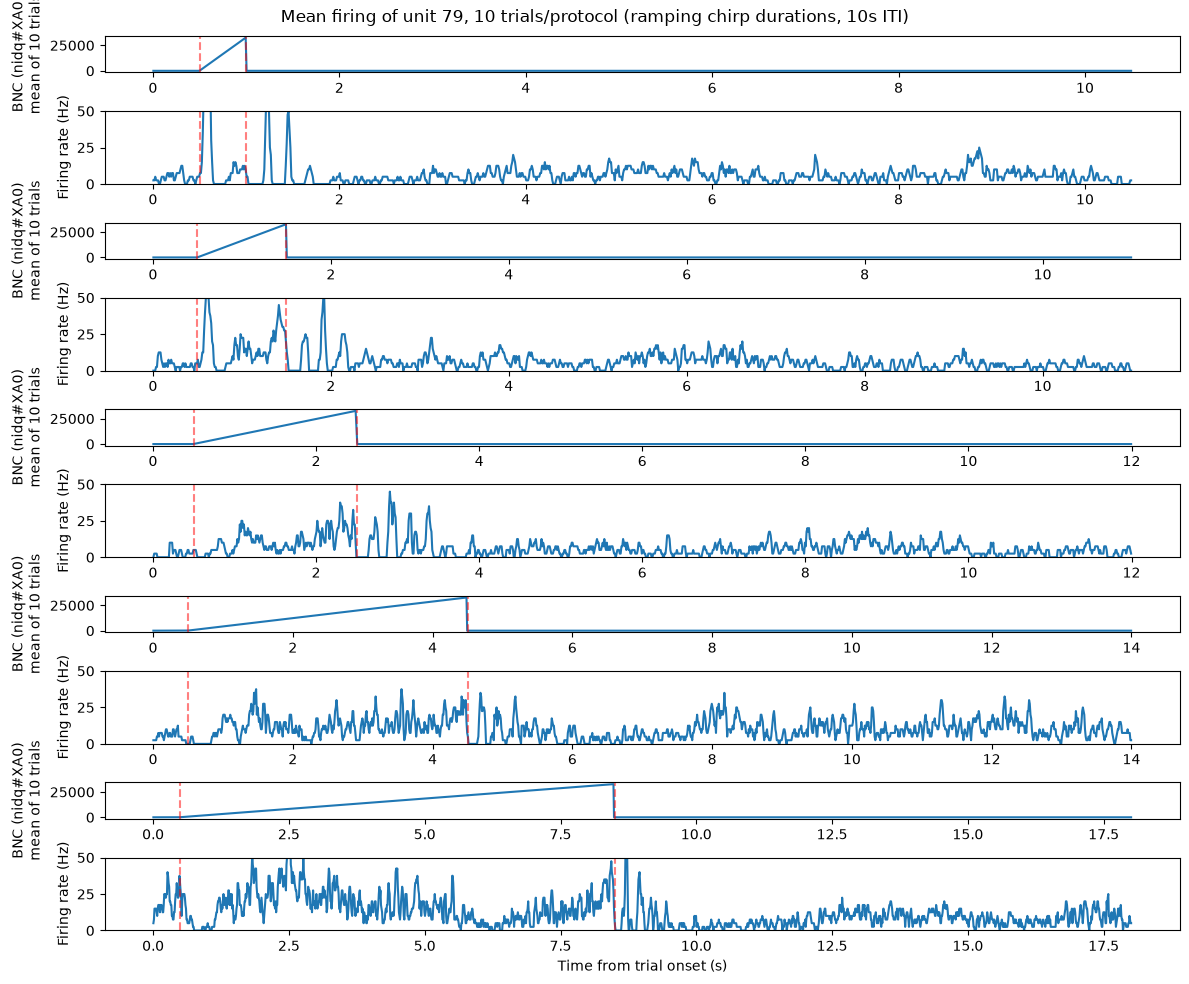

In [139]:
# psth for ramps
ramp_units = [79]
ramp_spike_times = {
    unit_id: unit_data[unit_id]["spike_times_s"]
    for unit_id in ramp_units
}
print(f"Selected {len(ramp_units)} ramp units for downstream analysis")

start_time = [2970.0, 2980.5, 2991.5, 3003.5, 3017.5]

n_freqs = 5
chirp_s = [0.5, 1, 2, 4, 8]                  # chirp stimulus duration (s)
iti_s = 10                    # inter-trial interval duration (s)
n_trials = 10                 # number of sets (repeats) to average per protocol
bin_size_s = 0.01             # firing-rate bin width (s)
smooth_bins = 4               # moving-average window, in bins

lapse_s = [c + iti_s for c in chirp_s]  # window length per trial, per protocol (s)
trial_period_s = sum(lapse_s)            # spacing between repeats of the same protocol (one full cycle through all 5)

n_units = len(ramp_spike_times)

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]
    # each ramp protocol occupies 2 sub-rows (bnc on top, rate below), so the full
    # grid is (2 * n_freqs) rows x 1 column
    fig, axes = plt.subplots(
        2 * n_freqs, 1, figsize=(12, 2 * n_freqs),
        gridspec_kw={"height_ratios": [1, 2] * n_freqs}, squeeze=False,
    )
else:
    fig, axes = plt.subplots(n_freqs, 1, figsize=(12, 2 * n_freqs), squeeze=False)

for i in range(n_freqs):
    first_trial_start_s = start_time[i]
    protocol_lapse_s = lapse_s[i]
    trial_start_times = np.array([first_trial_start_s + t * trial_period_s for t in range(n_trials)]).flatten()

    # each protocol has its own chirp duration, so its own bin grid
    bin_edges = np.arange(0, protocol_lapse_s + bin_size_s, bin_size_s)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    trial_rates = []
    trial_bnc_traces = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the nominal cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + protocol_lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, 100, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + protocol_lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in ramp_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

        if show_bnc:
            bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, trial_start, trial_end)
            trial_bnc_traces.append(np.interp(bin_centers, bnc_time - trial_start, bnc_trace))

    trial_rates = np.array(trial_rates)
    mean_rate = trial_rates.mean(axis=0)
    smoothed_rate = np.convolve(mean_rate, np.ones(smooth_bins) / smooth_bins, mode="same")

    if show_bnc:
        rate_ax = axes[i * 2 + 1, 0]
        bnc_ax = axes[i * 2, 0]
        trial_bnc_traces = np.array(trial_bnc_traces)
        mean_bnc = trial_bnc_traces.mean(axis=0)
        bnc_ax.plot(bin_centers, mean_bnc)
        bnc_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
        bnc_ax.axvline(0.5 + chirp_s[i], color="red", linestyle="--", alpha=0.5)
        bnc_ax.set_ylabel(f"BNC ({bnc_channel_id})\nmean of {n_trials} trials")
        # bnc_ax.set_title(f"{chirp_s[i]}s chirp")
    else:
        rate_ax = axes[i, 0]
        rate_ax.set_title(f"{chirp_s[i]}s chirp")

    rate_ax.plot(bin_centers, smoothed_rate)
    rate_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    rate_ax.axvline(0.5 + chirp_s[i], color="red", linestyle="--", alpha=0.5)
    rate_ax.set_ylim(0, 50)
    rate_ax.set_ylabel("Firing rate (Hz)")
rate_ax.set_xlabel("Time from trial onset (s)")

fig.suptitle(f"Mean firing of unit {ramp_units[0]}, {n_trials} trials/protocol (ramping chirp durations, {iti_s}s ITI)")
plt.tight_layout()
plt.show()

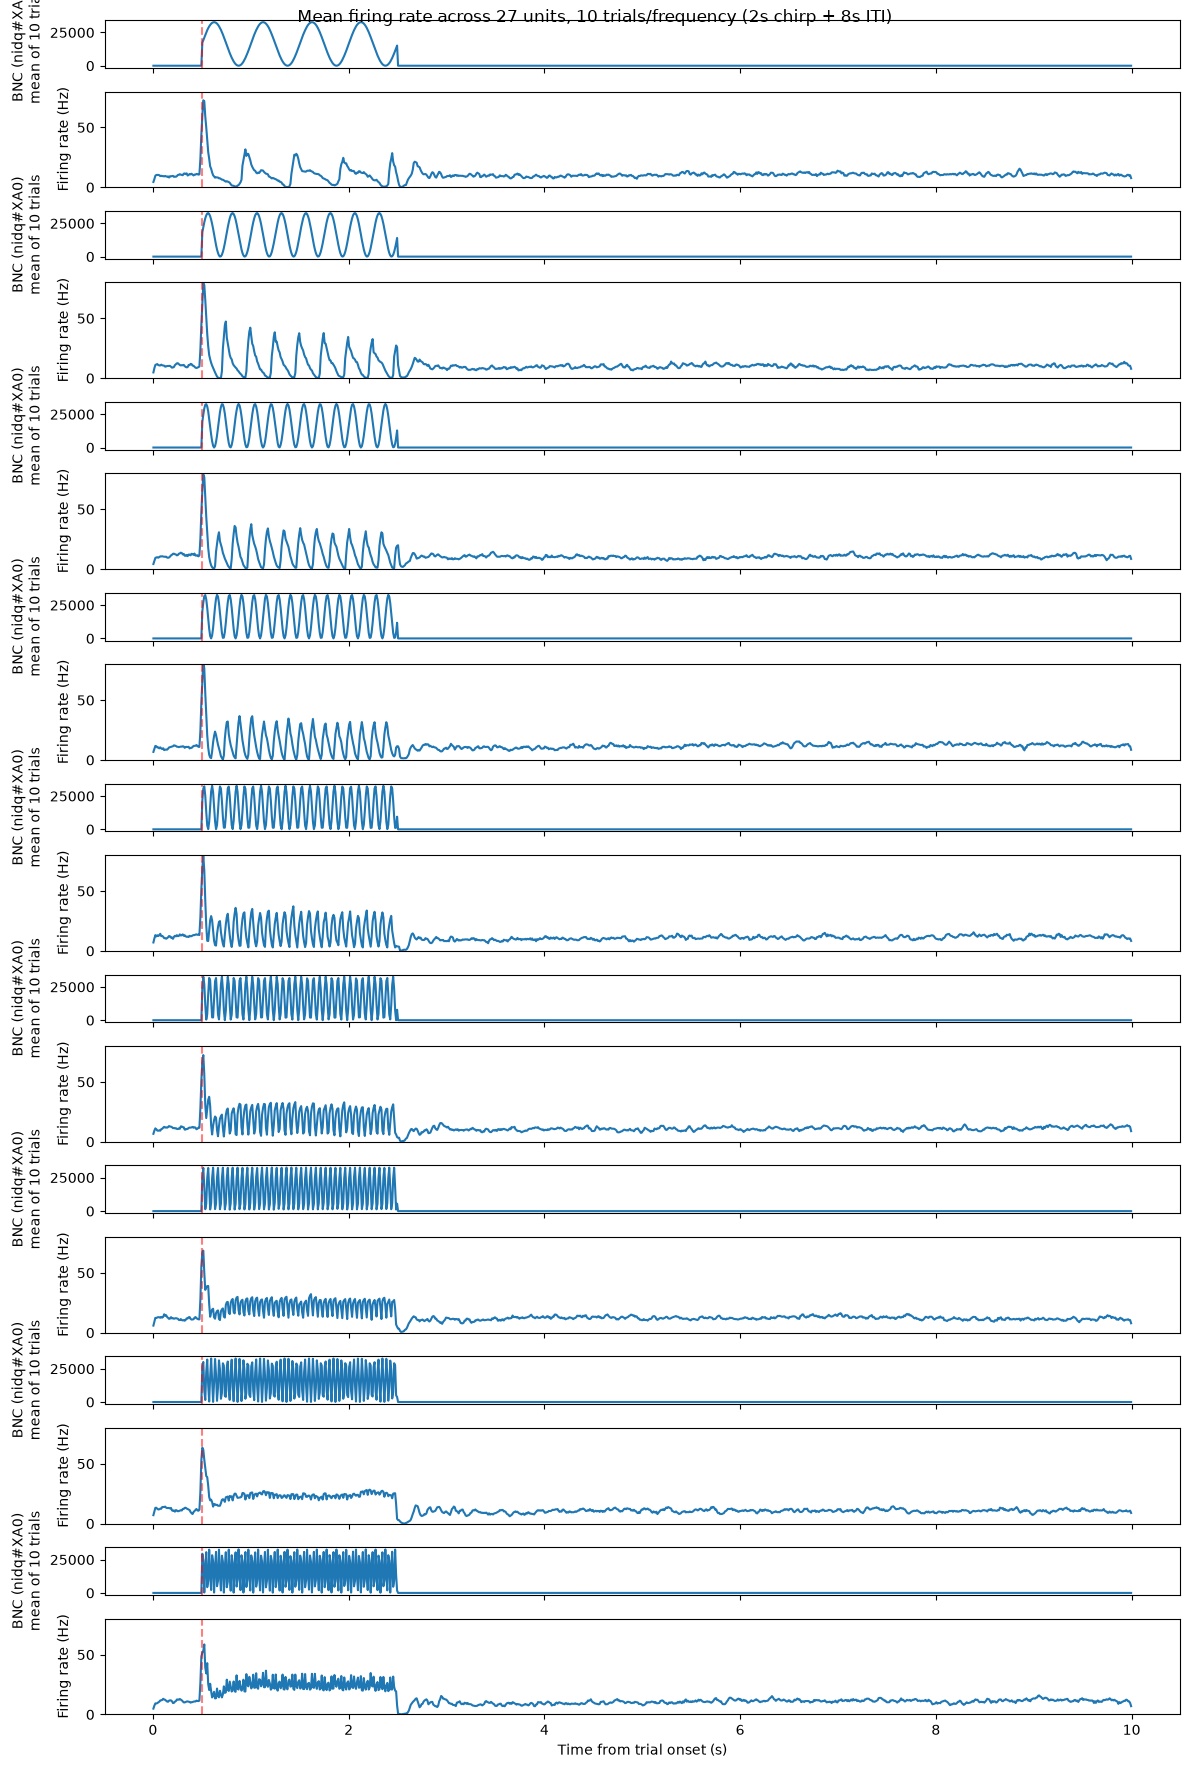

In [75]:
# --- Trial-averaged firing rate + BNC trace, one panel per frequency (6 rows x 1 col) ---
# Trial structure: 6 frequencies, each trial = 2s chirp + 8s ITI (10s/trial), cycling
# through all 6 frequencies before repeating -> same frequency recurs every 60s.
# 10 sets per frequency -> 6 * 10 = 60 trials total.
start_time = 4680.0

n_freqs = 9
chirp_s = 2                  # chirp stimulus duration (s)
iti_s = 8                    # inter-trial interval duration (s)
lapse_s = chirp_s + iti_s    # window length per trial (s)
trial_period_s = n_freqs * lapse_s  # spacing between repeats of the same frequency (60s)
n_trials = 10                 # number of sets (repeats) to average per frequency
bin_size_s = 0.01             # firing-rate bin width (s)
smooth_bins = 4               # moving-average window, in bins
plot_xlim_s = (0, 1.5)          # display window only (data is still computed over the full lapse_s)

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
n_units = len(lgn_spike_times)

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]
    # each frequency panel occupies 2 sub-rows (bnc on top, rate below), so the full
    # grid is (2 * n_freqs) rows x 1 column
    fig, axes = plt.subplots(
        2 * n_freqs, 1, sharex=True, figsize=(12, 2 * n_freqs),
        gridspec_kw={"height_ratios": [1, 2] * n_freqs}, squeeze=False,
    )
else:
    fig, axes = plt.subplots(n_freqs, 1, sharex=True, sharey=True, figsize=(12, 2 * n_freqs), squeeze=False)

for i in range(n_freqs):
    first_trial_start_s = start_time + lapse_s * i
    trial_start_times = np.array([first_trial_start_s + t * trial_period_s for t in range(n_trials)]).flatten()

    trial_rates = []
    trial_bnc_traces = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the nominal cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

        if show_bnc:
            bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, trial_start, trial_end)
            trial_bnc_traces.append(np.interp(bin_centers, bnc_time - trial_start, bnc_trace))

    trial_rates = np.array(trial_rates)
    mean_rate = trial_rates.mean(axis=0)
    smoothed_rate = np.convolve(mean_rate, np.ones(smooth_bins) / smooth_bins, mode="same")

    if show_bnc:
        rate_ax = axes[i * 2 + 1, 0]
        bnc_ax = axes[i * 2, 0]
        trial_bnc_traces = np.array(trial_bnc_traces)
        mean_bnc = trial_bnc_traces.mean(axis=0)
        bnc_ax.plot(bin_centers, mean_bnc)
        bnc_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
        bnc_ax.set_ylabel(f"BNC ({bnc_channel_id})\nmean of {n_trials} trials")
    else:
        rate_ax = axes[i, 0]

    rate_ax.plot(bin_centers, smoothed_rate)
    rate_ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    rate_ax.set_ylim(0, 80)
    rate_ax.set_ylabel("Firing rate (Hz)")
rate_ax.set_xlabel("Time from trial onset (s)")

# data above is still computed over the full lapse_s window; this just restricts the
# displayed x-range (sharex=True propagates it to every panel)
# axes[-1, 0].set_xlim(*plot_xlim_s)

fig.suptitle(f"Mean firing rate across {n_units} units, {n_trials} trials/frequency ({chirp_s}s chirp + {iti_s}s ITI)")
plt.tight_layout()
plt.show()

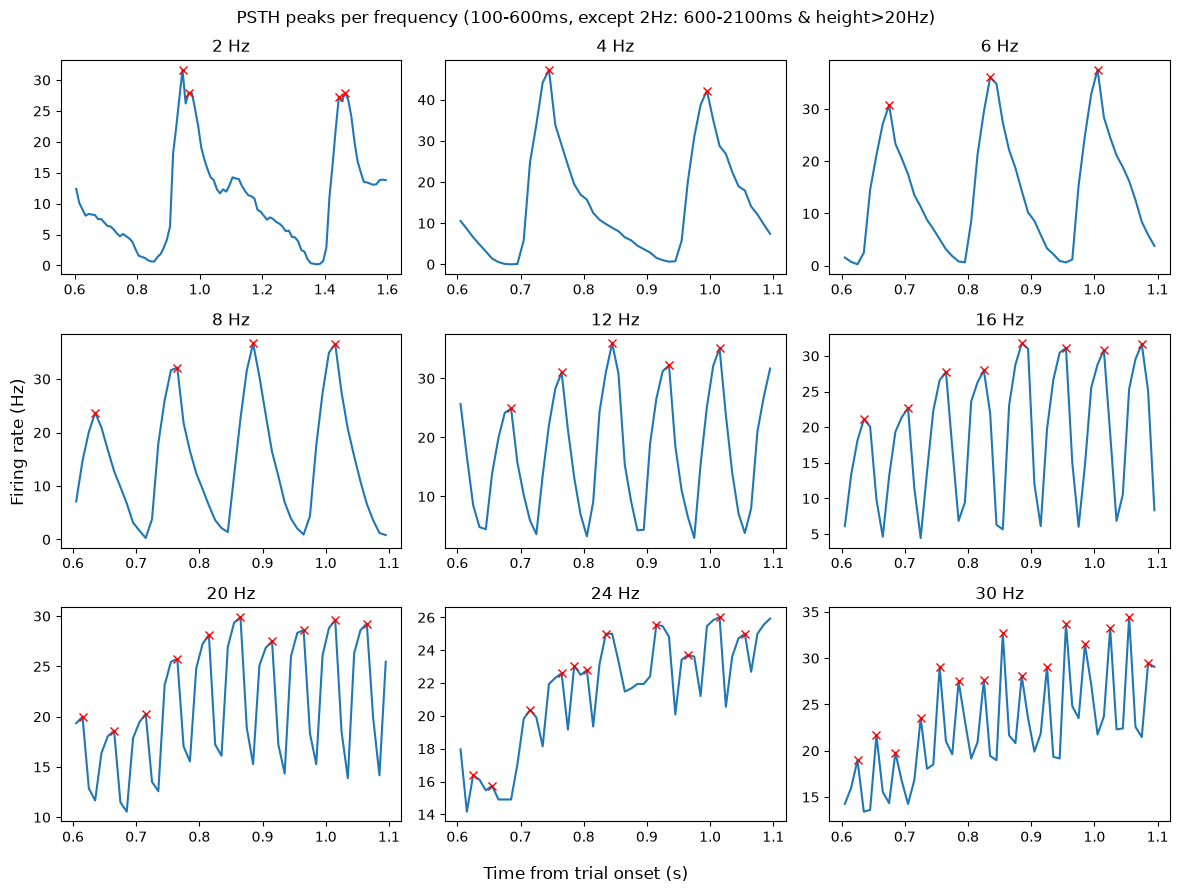

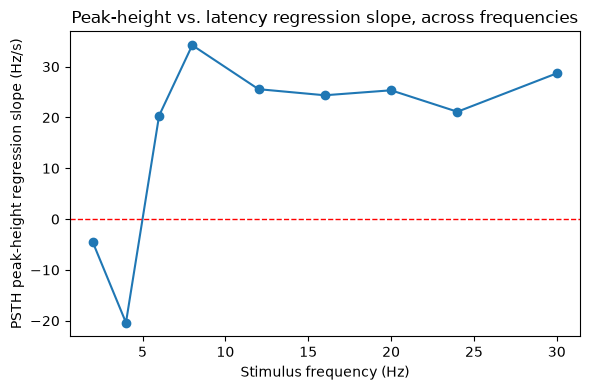

In [87]:
# --- PSTH peak-height regression vs. stimulus frequency ---
# For each of the 9 stimulus frequencies, find every local peak of the trial-averaged,
# smoothed PSTH within 100-600ms after chirp onset, then fit peak height vs. peak
# latency with a linear regression. The resulting slope (per frequency) is plotted
# against stimulus frequency. Trial extraction mirrors cell 10 (2s chirp + 8s ITI,
# 10 repeats/frequency), but recomputed here since this experiment has 9 conditions,
# not 6, and cell 10's loop variables only retain its last iteration.
# The 2Hz condition behaves differently (slower response), so it gets its own peak
# window (600-2100ms instead of 100-600ms) and a minimum accepted peak height (20Hz).
from scipy.signal import find_peaks
from scipy.stats import linregress

stim_freqs_hz = [2, 4, 6, 8, 12, 16, 20, 24, 30]
n_freqs = len(stim_freqs_hz)

start_time = 4680.0
chirp_s = 2                  # chirp stimulus duration (s)
iti_s = 8                    # inter-trial interval duration (s)
lapse_s = chirp_s + iti_s    # window length per trial (s)
trial_period_s = n_freqs * lapse_s  # spacing between repeats of the same frequency
n_trials = 10                 # number of sets (repeats) to average per frequency
bin_size_s = 0.01             # firing-rate bin width (s)
smooth_bins = 4               # moving-average window, in bins

default_peak_window_s = (0.6, 1.1)     # peak-search window relative to trial onset (s)
freq_peak_window_s = {2: (0.6, 1.6)}   # per-frequency overrides
freq_min_peak_height_hz = {2: 20.0}    # per-frequency minimum accepted peak height (Hz)

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
n_units = len(lgn_spike_times)

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

freq_slopes = []
segment_by_freq = {}
peak_idx_by_freq = {}
peak_window_times_by_freq = {}

for i, freq_hz in enumerate(stim_freqs_hz):
    first_trial_start_s = start_time + lapse_s * i
    trial_start_times = np.array([first_trial_start_s + t * trial_period_s for t in range(n_trials)]).flatten()

    trial_rates = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster / cell 10
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

    trial_rates = np.array(trial_rates)
    mean_rate = trial_rates.mean(axis=0)
    smoothed_rate = np.convolve(mean_rate, np.ones(smooth_bins) / smooth_bins, mode="same")

    peak_window_s = freq_peak_window_s.get(freq_hz, default_peak_window_s)
    min_peak_height = freq_min_peak_height_hz.get(freq_hz)
    in_peak_window = (bin_centers >= peak_window_s[0]) & (bin_centers < peak_window_s[1])
    peak_window_times = bin_centers[in_peak_window]

    segment = smoothed_rate[in_peak_window]
    peak_idx, _ = find_peaks(segment, height=min_peak_height)
    peak_heights = segment[peak_idx]
    peak_times = peak_window_times[peak_idx]

    segment_by_freq[freq_hz] = segment
    peak_idx_by_freq[freq_hz] = peak_idx
    peak_window_times_by_freq[freq_hz] = peak_window_times

    freq_slopes.append(linregress(peak_times, peak_heights).slope if peak_idx.size >= 2 else np.nan)

# --- Diagnostic: smoothed PSTH in the peak-search window with detected peaks, per frequency ---
ncols = 3
nrows = int(np.ceil(n_freqs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
for i, freq_hz in enumerate(stim_freqs_hz):
    ax = axes[i // ncols][i % ncols]
    segment = segment_by_freq[freq_hz]
    peak_idx = peak_idx_by_freq[freq_hz]
    peak_window_times = peak_window_times_by_freq[freq_hz]
    ax.plot(peak_window_times, segment)
    ax.plot(peak_window_times[peak_idx], segment[peak_idx], "rx")
    ax.set_title(f"{freq_hz} Hz")
for i in range(n_freqs, nrows * ncols):
    axes[i // ncols][i % ncols].axis("off")
fig.supxlabel("Time from trial onset (s)")
fig.supylabel("Firing rate (Hz)")
fig.suptitle("PSTH peaks per frequency (100-600ms, except 2Hz: 600-2100ms & height>20Hz)")
plt.tight_layout()
plt.show()

# --- Regression slope (peak height vs. peak latency) vs. stimulus frequency ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(stim_freqs_hz, freq_slopes, "o-")
ax.set_xlabel("Stimulus frequency (Hz)")
ax.set_ylabel("PSTH peak-height regression slope (Hz/s)")
ax.set_title("Peak-height vs. latency regression slope, across frequencies")
ax.axhline(0.0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

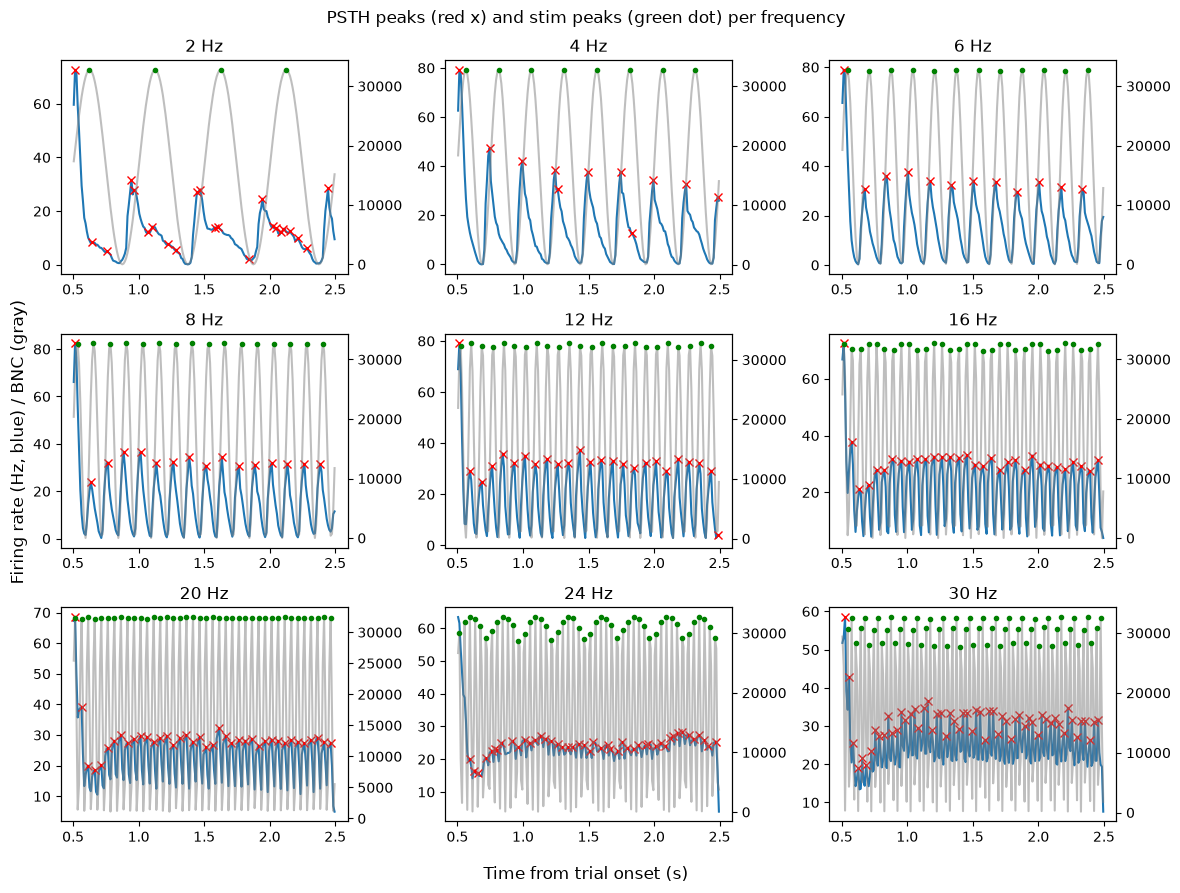

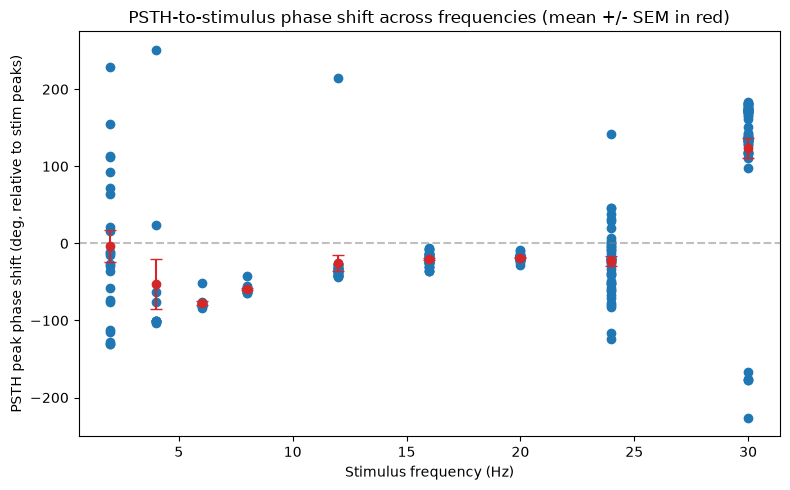

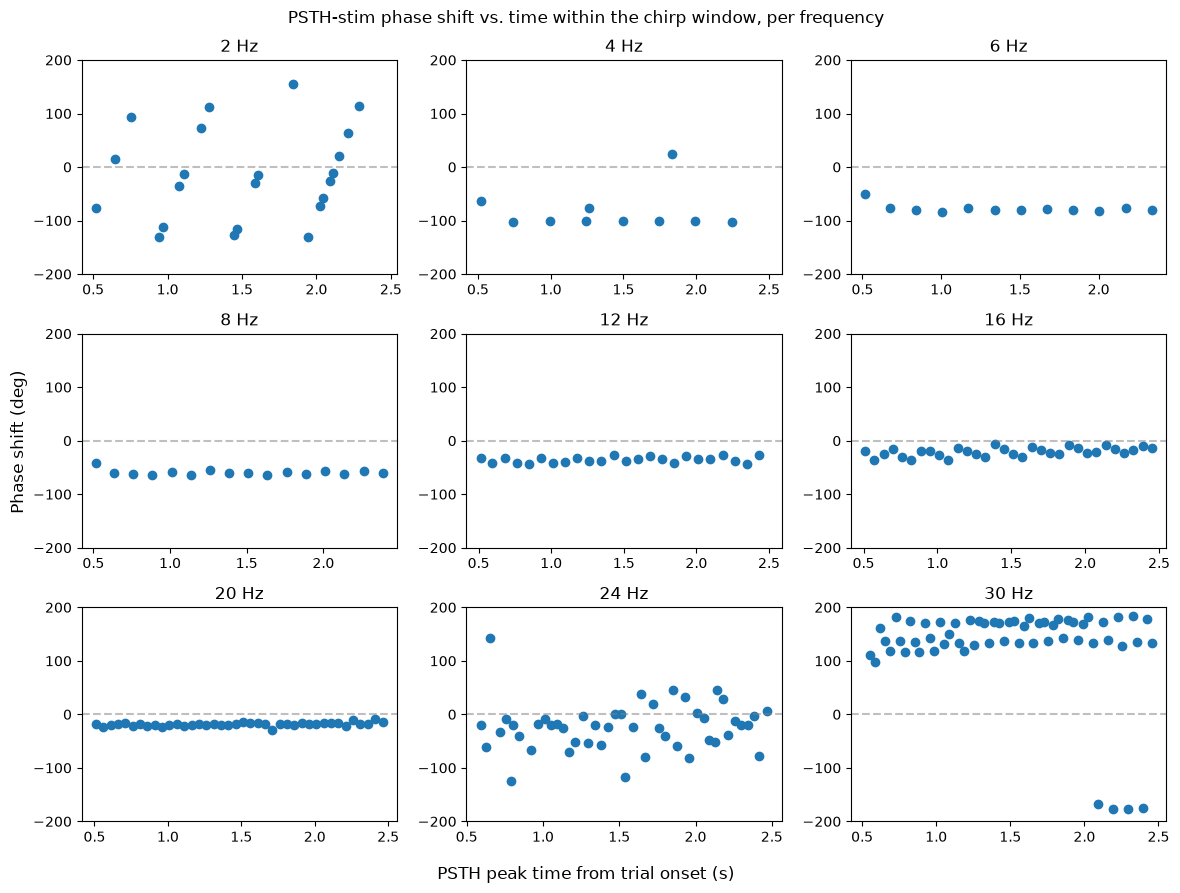

In [96]:
# --- PSTH peak phase shift relative to the sinusoidal stimulus, per frequency ---
# The stimulus waveform is taken from the trial-averaged BNC/photodiode trace (same
# extraction as cell 10) rather than an assumed ideal sinusoid, since it's the actual
# measured stimulus. Its peaks mark the true stimulus phase within the chirp
# presentation window (0.5-2.5s in the trial-aligned timeline, since trials are
# re-centered 0.5s before the detected chirp onset - see axvline(0.5) in cells 10/11).
#
# PSTH peaks are matched to their nearest stim peak; the time offset is converted to
# phase by multiplying by frequency, so the same absolute time shift is a larger phase
# at higher frequencies (criterion 1). Peak times are refined to sub-bin precision via
# parabolic interpolation, so phase shifts aren't quantized to the 10ms bin grid.
from scipy.signal import find_peaks

def _refine_peak_time(segment, idx, times, dt):
    if idx <= 0 or idx >= len(segment) - 1:
        return times[idx]
    y0, y1, y2 = segment[idx - 1], segment[idx], segment[idx + 1]
    denom = y0 - 2 * y1 + y2
    if denom == 0:
        return times[idx]
    offset = np.clip(0.5 * (y0 - y2) / denom, -0.5, 0.5)
    return times[idx] + offset * dt

stim_freqs_hz = [2, 4, 6, 8, 12, 16, 20, 24, 30]
n_freqs = len(stim_freqs_hz)

start_time = 4680.0
chirp_s = 2                  # chirp stimulus duration (s)
iti_s = 8                    # inter-trial interval duration (s)
lapse_s = chirp_s + iti_s    # window length per trial (s)
trial_period_s = n_freqs * lapse_s  # spacing between repeats of the same frequency
n_trials = 10                 # number of sets (repeats) to average per frequency
bin_size_s = 0.01             # firing-rate bin width (s)
smooth_bins = 4               # moving-average window, in bins

chirp_window_s = (0.5, 0.5 + chirp_s)  # actual stimulus presentation window, trial-aligned

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
n_units = len(lgn_spike_times)

nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
nidq_fs = nidq_recording.get_sampling_frequency()
bnc_channel_id = nidq_recording.channel_ids[0]

in_chirp_window = (bin_centers >= chirp_window_s[0]) & (bin_centers < chirp_window_s[1])
chirp_window_times = bin_centers[in_chirp_window]

phase_shifts_by_freq = {}
rate_peak_times_by_freq = {}
rate_segment_by_freq = {}
bnc_segment_by_freq = {}
rate_peak_idx_by_freq = {}
stim_peak_idx_by_freq = {}

for i, freq_hz in enumerate(stim_freqs_hz):
    first_trial_start_s = start_time + lapse_s * i
    trial_start_times = np.array([first_trial_start_s + t * trial_period_s for t in range(n_trials)]).flatten()

    trial_rates = []
    trial_bnc_traces = []
    for nominal_start in trial_start_times:
        trial_start = nominal_start
        # re-center each trial on its actual chirp onset, same logic as plot_raster / cell 10
        search_time, search_trace = _load_bnc_window(
            nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
        )
        onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
        if onsets.size:
            trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        trial_rates.append(counts / (bin_size_s * n_units))

        bnc_time, bnc_trace = _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, trial_start, trial_end)
        trial_bnc_traces.append(np.interp(bin_centers, bnc_time - trial_start, bnc_trace))

    trial_rates = np.array(trial_rates)
    mean_rate = trial_rates.mean(axis=0)
    smoothed_rate = np.convolve(mean_rate, np.ones(smooth_bins) / smooth_bins, mode="same")

    trial_bnc_traces = np.array(trial_bnc_traces)
    mean_bnc = trial_bnc_traces.mean(axis=0)

    rate_segment = smoothed_rate[in_chirp_window]
    bnc_segment = mean_bnc[in_chirp_window]

    # same find_peaks call as cell 11: no distance/height constraint
    rate_peak_idx, _ = find_peaks(rate_segment)
    stim_peak_idx, _ = find_peaks(bnc_segment)

    rate_segment_by_freq[freq_hz] = rate_segment
    bnc_segment_by_freq[freq_hz] = bnc_segment
    rate_peak_idx_by_freq[freq_hz] = rate_peak_idx
    stim_peak_idx_by_freq[freq_hz] = stim_peak_idx

    rate_peak_times = np.array([
        _refine_peak_time(rate_segment, idx, chirp_window_times, bin_size_s) for idx in rate_peak_idx
    ])
    stim_peak_times = np.array([
        _refine_peak_time(bnc_segment, idx, chirp_window_times, bin_size_s) for idx in stim_peak_idx
    ])

    rate_peak_times_by_freq[freq_hz] = rate_peak_times

    if rate_peak_times.size and stim_peak_times.size:
        # match each PSTH peak to its nearest stim peak, then scale the time offset by
        # frequency to get phase (so the same time shift is a bigger phase at higher freq)
        nearest_stim_idx = np.abs(rate_peak_times[:, None] - stim_peak_times[None, :]).argmin(axis=1)
        time_shifts_s = rate_peak_times - stim_peak_times[nearest_stim_idx]
        phase_shifts_by_freq[freq_hz] = time_shifts_s * freq_hz * 360  # degrees
    else:
        phase_shifts_by_freq[freq_hz] = np.array([])

# --- Diagnostic: PSTH (with detected peaks) and stim/BNC trace (with its own detected
# peaks) in the chirp window, per frequency - same layout as cell 11's diagnostic grid ---
ncols = 3
nrows = int(np.ceil(n_freqs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
for i, freq_hz in enumerate(stim_freqs_hz):
    rate_ax = axes[i // ncols][i % ncols]
    rate_segment = rate_segment_by_freq[freq_hz]
    bnc_segment = bnc_segment_by_freq[freq_hz]
    rate_peak_idx = rate_peak_idx_by_freq[freq_hz]
    stim_peak_idx = stim_peak_idx_by_freq[freq_hz]

    rate_ax.plot(chirp_window_times, rate_segment, color="tab:blue")
    rate_ax.plot(chirp_window_times[rate_peak_idx], rate_segment[rate_peak_idx], "rx")
    rate_ax.set_title(f"{freq_hz} Hz")

    bnc_ax = rate_ax.twinx()
    bnc_ax.plot(chirp_window_times, bnc_segment, color="tab:gray", alpha=0.5)
    bnc_ax.plot(chirp_window_times[stim_peak_idx], bnc_segment[stim_peak_idx], "g.")
for i in range(n_freqs, nrows * ncols):
    axes[i // ncols][i % ncols].axis("off")
fig.supxlabel("Time from trial onset (s)")
fig.supylabel("Firing rate (Hz, blue) / BNC (gray)")
fig.suptitle("PSTH peaks (red x) and stim peaks (green dot) per frequency")
plt.tight_layout()
plt.show()

# --- Plot: PSTH peak phase shift (relative to stim peaks) per frequency ---
fig, ax = plt.subplots(figsize=(8, 5))
for freq_hz in stim_freqs_hz:
    shifts = phase_shifts_by_freq[freq_hz]
    ax.scatter([freq_hz] * shifts.size, shifts, color="tab:blue", alpha=1.0, zorder=2)
    if shifts.size:
        sem = shifts.std(ddof=1) / np.sqrt(shifts.size) if shifts.size > 1 else 0
        ax.errorbar(freq_hz, shifts.mean(), yerr=sem, fmt="o", color="tab:red", capsize=4, zorder=3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Stimulus frequency (Hz)")
ax.set_ylabel("PSTH peak phase shift (deg, relative to stim peaks)")
ax.set_title("PSTH-to-stimulus phase shift across frequencies (mean +/- SEM in red)")
plt.tight_layout()
plt.show()

# --- Plot: phase shift vs. time within the chirp window, one panel per frequency ---
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
for i, freq_hz in enumerate(stim_freqs_hz):
    ax = axes[i // ncols][i % ncols]
    ax.scatter(rate_peak_times_by_freq[freq_hz], phase_shifts_by_freq[freq_hz], color="tab:blue")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"{freq_hz} Hz")
    ax.set_ylim(-200,200)
for i in range(n_freqs, nrows * ncols):
    axes[i // ncols][i % ncols].axis("off")
fig.supxlabel("PSTH peak time from trial onset (s)")
fig.supylabel("Phase shift (deg)")
fig.suptitle("PSTH-stim phase shift vs. time within the chirp window, per frequency")
plt.tight_layout()
plt.show()

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


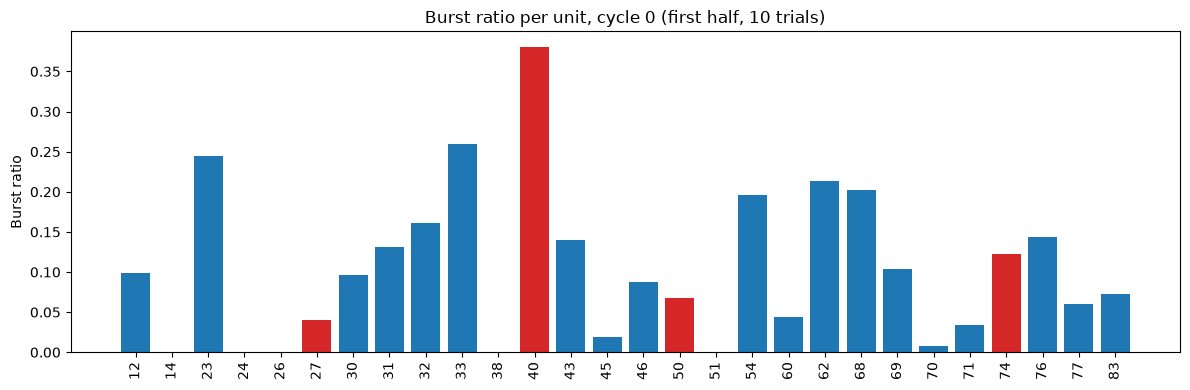

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


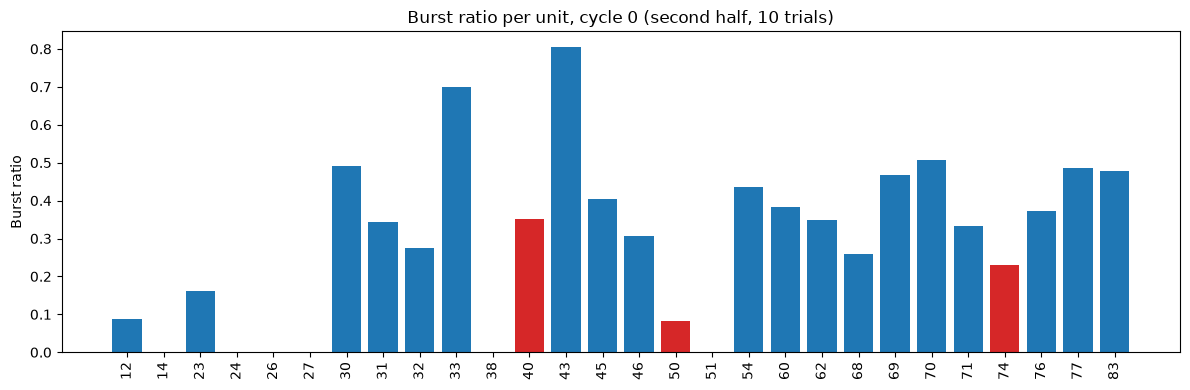

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


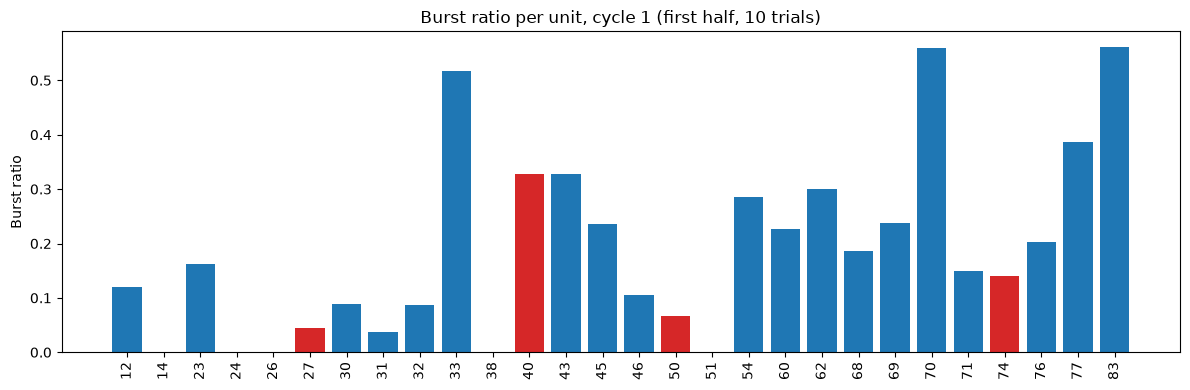

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


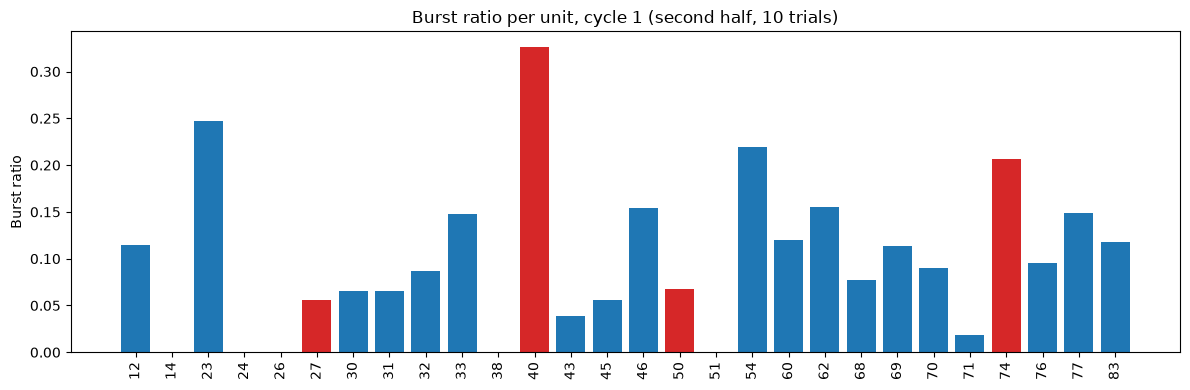

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


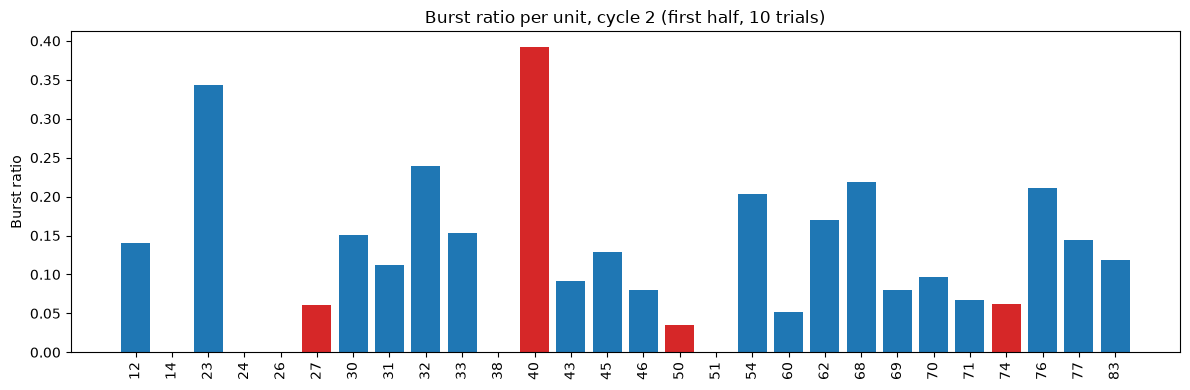

C:\Users\xw1030\AppData\Local\Temp\ipykernel_3232\3169440005.py:83: RuntimeWarning: Mean of empty slice
  per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)


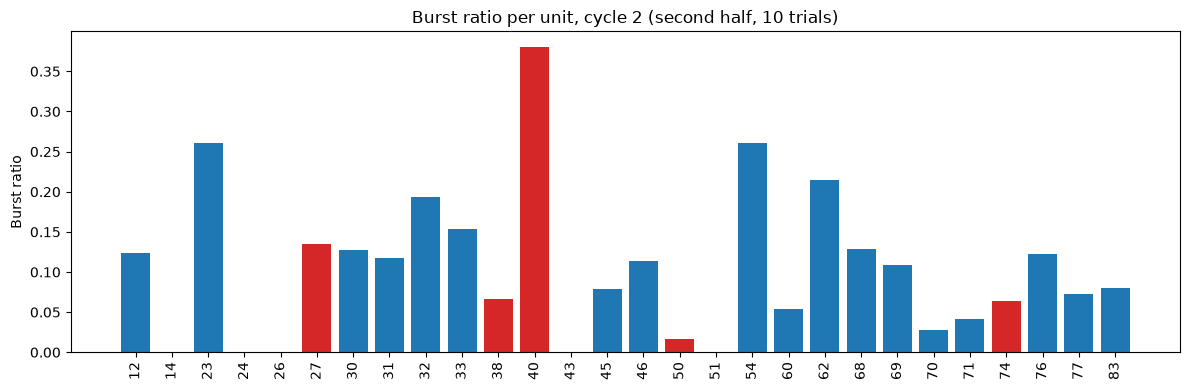

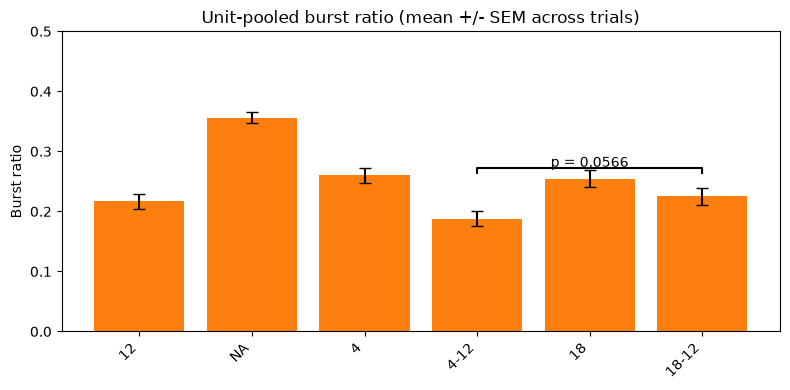

In [9]:
# --- Burst-spike identification: a spike is a "burst spike" if another spike from the
# same train falls within burst_isi_s of it (looking both backward and forward) ---
from scipy.stats import ttest_ind
anti_list = np.array([4, 5, 10, 11, 15, 24])

def identify_burst_spikes(spike_times, start_time_s=None, end_time_s=None, burst_isi_s=0.010):
    times = np.asarray(spike_times)
    if start_time_s is not None:
        times = times[times >= start_time_s]
    if end_time_s is not None:
        times = times[times < end_time_s]

    if times.size < 2:
        return np.zeros(times.size, dtype=bool)

    preceding_isi = np.diff(times, prepend=-np.inf)
    following_isi = np.diff(times, append=np.inf)
    is_burst = (preceding_isi <= burst_isi_s) | (following_isi <= burst_isi_s)
    return is_burst


# quantify burst spikes for each LGN unit
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
# start_time = np.array([1893, 2971])  # [no-mask, mask]
start_time = 2971.0
lapse_s = 4  # covers trial_start_1..trial_end_2 below (two 2s halves)
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

pooled_ratios = []
pooled_sems = []
pooled_trial_ratios = []
pooled_labels = []

for i in range(3):
    first_trial_start_s = start_time + cycle_start[i]
    trial_period_s = 90       # nominal spacing between trials
    n_trials = 10                # number of trials to average

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    show_bnc = bool(nidq_file_path)
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        search_time, search_trace = _load_bnc_window(
            nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
        )
        onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
        if onsets.size:
            trial_start = onsets[0]
        trial_start_times[k] = trial_start

    num_burst_1 = np.zeros((len(trial_start_times), n_units, 2))
    num_burst_2 = np.zeros((len(trial_start_times), n_units, 2))

    for u, (unit_id, times) in enumerate(lgn_spike_times.items()):
        for t in range(len(trial_start_times)):
            trial_start_1 = trial_start_times[t]
            trial_end_1 = trial_start_1 + 2
            trial_start_2 = trial_end_1
            trial_end_2 = trial_start_2 + 2
            is_burst_1 = identify_burst_spikes(times, start_time_s=trial_start_1, end_time_s=trial_end_1)
            is_burst_2 = identify_burst_spikes(times, start_time_s=trial_start_2, end_time_s=trial_end_2)
            num_burst_1[t, u, 0] = is_burst_1.sum()
            num_burst_1[t, u, 1] = len(is_burst_1) - is_burst_1.sum()
            num_burst_2[t, u, 0] = is_burst_2.sum()
            num_burst_2[t, u, 1] = len(is_burst_2) - is_burst_2.sum()

    # --- Bar graph: per-unit burst ratio (ratio per trial, then averaged across trials) ---
    for half_idx, (window_label, num_burst) in enumerate((("first half", num_burst_1), ("second half", num_burst_2))):
        with np.errstate(invalid="ignore", divide="ignore"):
            per_trial_ratio = num_burst[..., 0] / num_burst.sum(axis=-1)  # (n_trials, n_units)
            per_unit_ratio = np.nanmean(per_trial_ratio, axis=0)         # (n_units,)

            # unit-pooled ratio: burst/non-burst counts summed across units per trial, then averaged across trials
            pooled_per_trial = num_burst.sum(axis=1)                    # (n_trials, 2): [burst, non-burst]
            pooled_ratio_per_trial = pooled_per_trial[:, 0] / pooled_per_trial.sum(axis=1)
            pooled_ratio = np.nanmean(pooled_ratio_per_trial)
            pooled_sem = np.nanstd(pooled_ratio_per_trial, ddof=1) / np.sqrt(np.sum(~np.isnan(pooled_ratio_per_trial)))

        pooled_ratios.append(pooled_ratio)
        pooled_sems.append(pooled_sem)
        pooled_trial_ratios.append(pooled_ratio_per_trial)
        pooled_labels.append(stim_hz[i * 2 + half_idx])

        fig, ax = plt.subplots(figsize=(max(12, 0.3 * n_units), 4))
        bar_colors = ["tab:red" if i in anti_list else "tab:blue" for i in range(n_units)]
        ax.bar(np.arange(n_units), per_unit_ratio, color=bar_colors)
        ax.set_xticks(np.arange(n_units))
        ax.set_xticklabels([str(u) for u in unit_ids], rotation=90)
        ax.set_ylabel("Burst ratio")
        ax.set_title(f"Burst ratio per unit, cycle {i} ({window_label}, {n_trials} trials)")
        plt.tight_layout()
        plt.show()

# --- Compare the unit-pooled burst ratio side by side, across all cycles/windows,
# with trial-to-trial SEM error bars and a t-test between "4-12" and "18-12" ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pooled_ratios))
ax.bar(x, pooled_ratios, yerr=pooled_sems, capsize=4, color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(pooled_labels, rotation=45, ha="right")
ax.set_ylabel("Burst ratio")
ax.set_title("Unit-pooled burst ratio (mean +/- SEM across trials)")

idx_a = pooled_labels.index("4-12")
idx_b = pooled_labels.index("18-12")
p_value = ttest_ind(pooled_trial_ratios[idx_a], pooled_trial_ratios[idx_b], nan_policy="omit").pvalue

bar_top = max(pooled_ratios[idx_a] + pooled_sems[idx_a], pooled_ratios[idx_b] + pooled_sems[idx_b])
bracket_y = bar_top * 1.1
ax.plot([idx_a, idx_a, idx_b, idx_b], [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y], color="black")
ax.text((idx_a + idx_b) / 2, bracket_y * 1.04, f"p = {p_value:.3g}", ha="center")
ax.set_ylim(0, 0.50)

plt.tight_layout()
plt.show()


In [ ]:
# --- Time-frequency spectrogram (frequency vs time) of the pooled LGN firing rate, averaged across trials ---
from scipy.signal import spectrogram



def plot_spectrogram(start_times_s, lapse_s, spike_times=None, bin_size_s=0.01, nperseg=128, noverlap=None):
    if spike_times is None:
        spike_times = lgn_spike_times

    start_times_s = np.atleast_1d(start_times_s).astype(float)
    n_trials = start_times_s.size
    n_units = len(spike_times)
    bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
    fs = 1.0 / bin_size_s

    freqs = spec_times = None
    Sxx_trials = []
    for trial_start_s in start_times_s:
        trial_end_s = trial_start_s + lapse_s
        pooled_spikes = np.concatenate([
            unit_times[(unit_times >= trial_start_s) & (unit_times < trial_end_s)] - trial_start_s
            for unit_times in spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        rate = counts / (bin_size_s * n_units)

        freqs, spec_times, Sxx = spectrogram(rate, fs=fs, nperseg=nperseg, noverlap=noverlap)
        Sxx_trials.append(Sxx)

    Sxx_mean = np.mean(Sxx_trials, axis=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    mesh = ax.pcolormesh(spec_times, freqs, 10 * np.log10(Sxx_mean + 1e-12), shading="gouraud")
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time from trial onset (s)")
    ax.set_ylabel("Frequency (Hz)")
    if n_trials > 1:
        ax.set_title(f"Spectrogram: {lapse_s:.2f}s window, averaged over {n_trials} trials")
    else:
        ax.set_title(f"Spectrogram: {start_times_s[0]:.2f}-{start_times_s[0] + lapse_s:.2f} s")
    plt.tight_layout()
    plt.show()
    return fig, ax, freqs, spec_times, Sxx_mean

# Example (single trial): fig, ax, freqs, times, Sxx = plot_spectrogram(start_times_s=1909.0, lapse_s=90.0)
# Example (averaged over trials): fig, ax, freqs, times, Sxx = plot_spectrogram(
#     start_times_s=[1909.0 + 90 * k for k in range(10)], lapse_s=8.0
# )


In [ ]:
# plot the spectrogram for each of the three cyclic trial windows, averaged across trials
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = np.array([1893, 2971])  # [no-mask, mask]

spec_bin_size_s = 0.005      # firing-rate bin width (s), same cadence as the trial-rate analysis above
spec_smooth_bins = 4       # moving-average window, in bins, for smoothing each unit's trial-averaged rate

for i in range(3):
    first_trial_start_s = start_time[0] + cycle_start[i]
    trial_period_s = 90       # nominal spacing between trials
    n_trials = 10                # number of trials to average
    lapse_s = 8.0                 # window length per trial, from each trial's aligned start

    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    show_bnc = bool(nidq_file_path)
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        search_time, search_trace = _load_bnc_window(
            nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
        )
        onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
        if onsets.size:
            trial_start = onsets[0]
        trial_start_times[k] = trial_start

    fig, ax, _, _, _ = plot_spectrogram(start_times_s=trial_start_times, lapse_s=lapse_s)

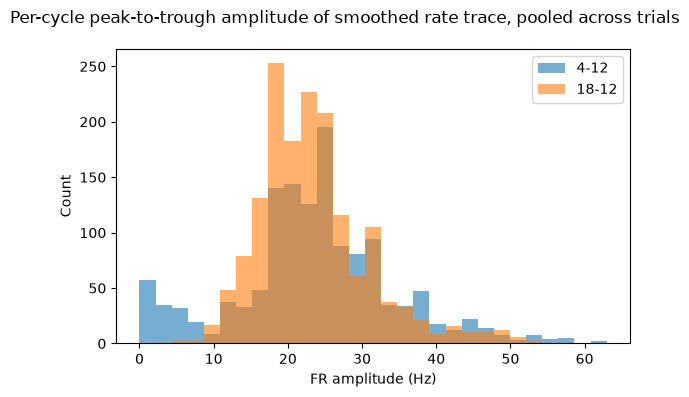

In [ ]:
# plot histogram of FR amplitude (peak-to-trough) for each LGN unit, across all trials in a given cycle
from scipy.signal import find_peaks

cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
# start_time = np.array([1893, 2971])  # [no-mask, mask]
start_time = 1921.0
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

trial_period_s = 90       # nominal spacing between trials
lapse_s = 8               # window length per trial, from each trial's aligned start
n_trials = 10                # number of trials to average
bin_size_s = 0.01            # firing-rate bin width (s)
smooth_bins = 4              # moving-average window, in bins

osc_freq_hz = 12.0                                        # assumed local oscillation frequency
min_extrema_distance_bins = max(1, int(round(0.5 / osc_freq_hz / bin_size_s)))  # ~half a 12Hz period

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

# each row of cycle_start is its own stimulus condition (row 1 = "4-12", row 2 = "18-12"),
# so each is thresholded and start-time-adjusted independently rather than sharing one
# vectorized chirp search - _load_bnc_window only accepts a scalar start time
amplitudes_by_row = {}
for cycle_row in (1, 2):
    first_trial_start_s = start_time + cycle_start[cycle_row]
    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    row_amplitudes = []
    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the ~90s cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        pooled_spikes = np.concatenate([
            times[(times >= trial_start) & (times < trial_end)] - trial_start
            for times in lgn_spike_times.values()
        ]) if n_units else np.array([])
        counts, _ = np.histogram(pooled_spikes, bins=bin_edges)
        rate = counts / (bin_size_s * n_units)
        smoothed_rate = np.convolve(rate, np.ones(smooth_bins) / smooth_bins, mode="same")

        in_window = (bin_centers >= 2) & (bin_centers < 4)
        segment = smoothed_rate[in_window]

        # every local peak and trough of the ~12Hz oscillation gets its own amplitude,
        # rather than one max-min scalar for the whole window
        peak_idx, _ = find_peaks(segment, distance=min_extrema_distance_bins)
        trough_idx, _ = find_peaks(-segment, distance=min_extrema_distance_bins)
        extrema_idx = np.sort(np.concatenate([peak_idx, trough_idx]))
        if extrema_idx.size >= 2:
            extrema_vals = segment[extrema_idx]
            row_amplitudes.extend(np.abs(np.diff(extrema_vals)).tolist())

    amplitudes_by_row[cycle_row] = row_amplitudes

amplitude_1_all = amplitudes_by_row[1]
amplitude_2_all = amplitudes_by_row[2]

# --- Histogram of every peak-to-trough amplitude of the smoothed-rate oscillation,
# pooled across all trials per condition, overlaid in a single panel ---
fig, ax = plt.subplots(figsize=(6, 4))
all_amps = np.concatenate([amplitude_1_all, amplitude_2_all])
bins = np.linspace(all_amps.min(), all_amps.max(), 30)
ax.hist(amplitude_1_all, bins=bins, color="tab:blue", alpha=0.6, label=stim_hz[3])
ax.hist(amplitude_2_all, bins=bins, color="tab:orange", alpha=0.6, label=stim_hz[5])
ax.set_xlabel("FR amplitude (Hz)")
ax.set_ylabel("Count")
ax.legend()

fig.suptitle("Per-cycle peak-to-trough amplitude of smoothed rate trace, pooled across trials")
plt.tight_layout()
plt.show()


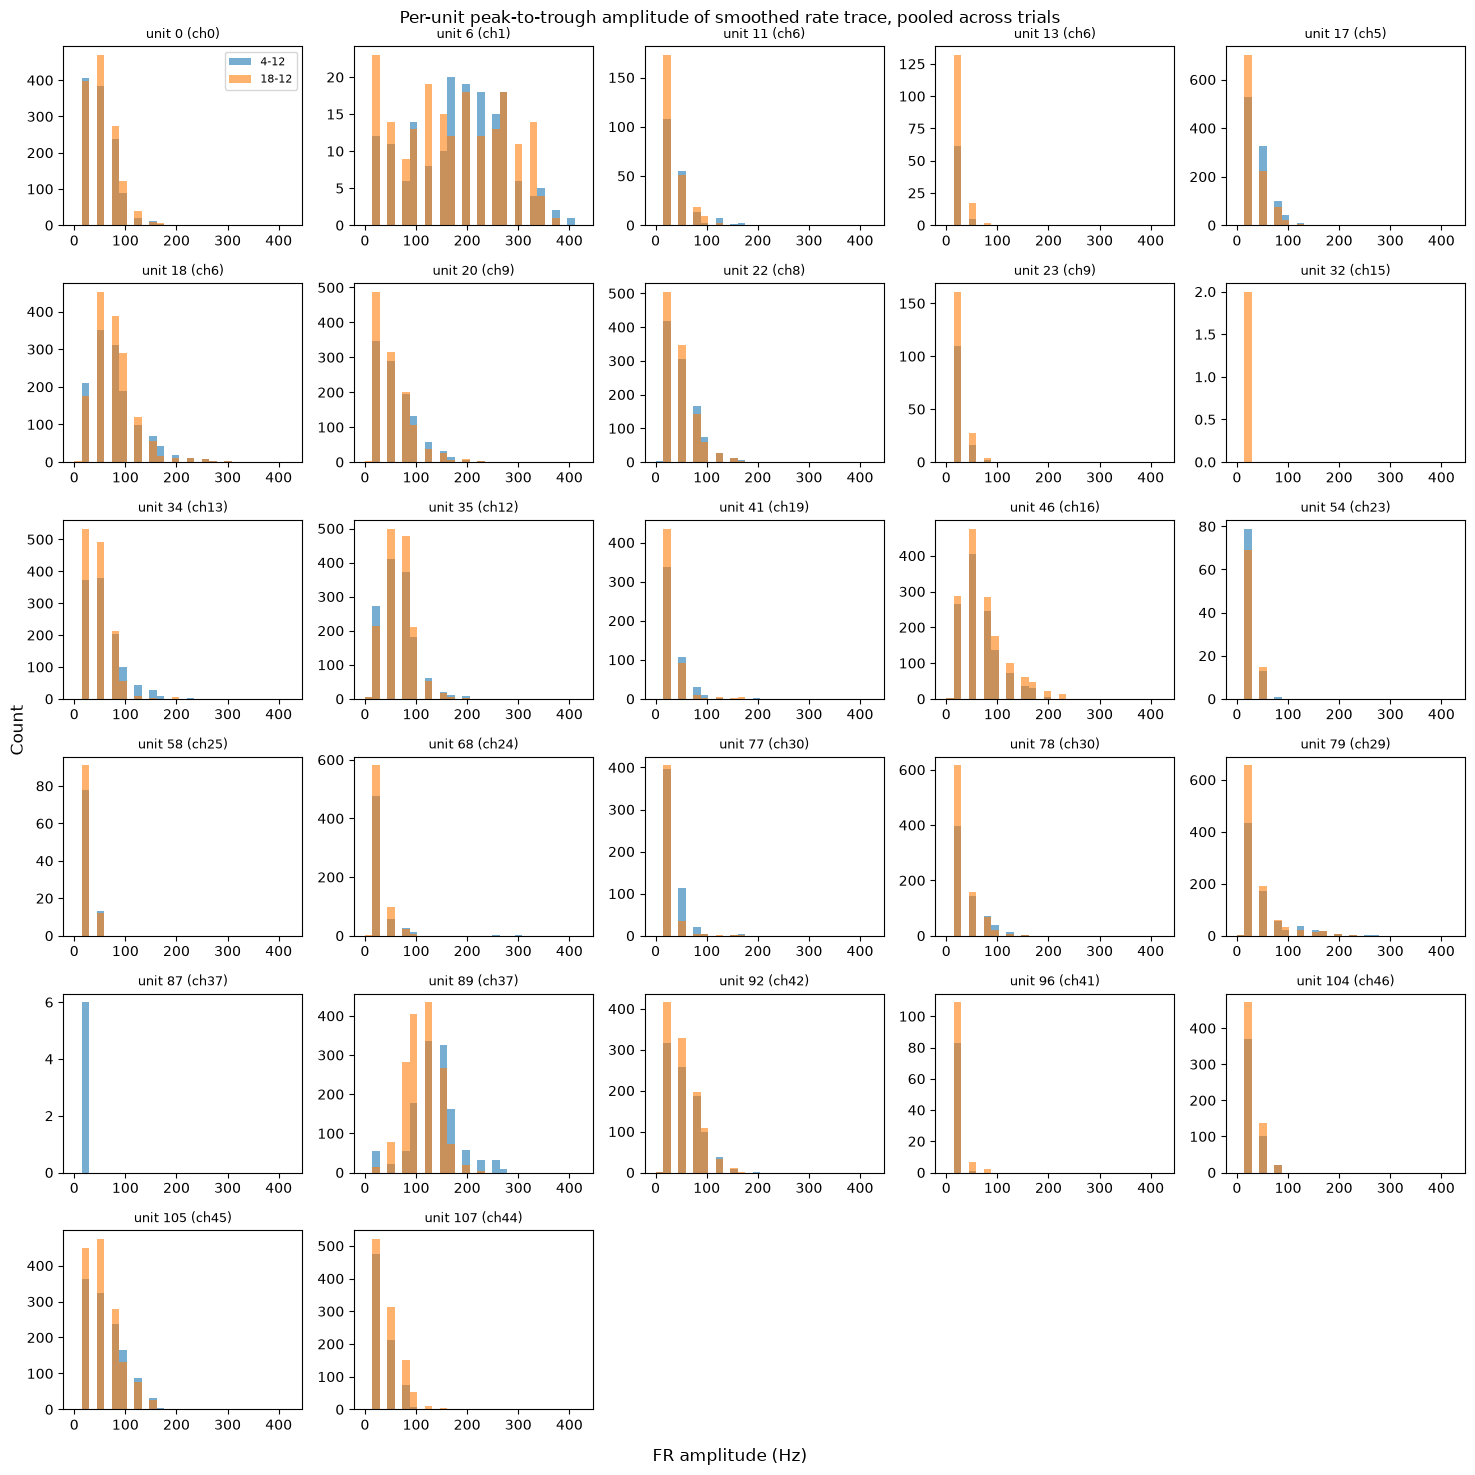

In [ ]:
# plot histogram of FR amplitude (peak-to-trough) per unit, one subplot per unit
from scipy.signal import find_peaks

cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
# start_time = np.array([1893, 2971])  # [no-mask, mask]
start_time = 1921.0
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

trial_period_s = 90       # nominal spacing between trials
lapse_s = 8               # window length per trial, from each trial's aligned start
n_trials = 10                # number of trials to average
bin_size_s = 0.01            # firing-rate bin width (s)
smooth_bins = 4              # moving-average window, in bins

osc_freq_hz = 12.0                                        # assumed local oscillation frequency
min_extrema_distance_bins = max(1, int(round(0.5 / osc_freq_hz / bin_size_s)))  # ~half a 12Hz period

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

# each row of cycle_start is its own stimulus condition (row 1 = "4-12", row 2 = "18-12"),
# so each is thresholded and start-time-adjusted independently rather than sharing one
# vectorized chirp search - _load_bnc_window only accepts a scalar start time
amplitudes_by_row = {}
for cycle_row in (1, 2):
    first_trial_start_s = start_time + cycle_start[cycle_row]
    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    unit_amplitudes = {unit_id: [] for unit_id in unit_ids}
    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the ~90s cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0] - 0.5
        trial_end = trial_start + lapse_s

        for unit_id, times in lgn_spike_times.items():
            window_spikes = times[(times >= trial_start) & (times < trial_end)] - trial_start
            counts, _ = np.histogram(window_spikes, bins=bin_edges)
            rate = counts / bin_size_s
            smoothed_rate = np.convolve(rate, np.ones(smooth_bins) / smooth_bins, mode="same")

            in_window = (bin_centers >= 2) & (bin_centers < 4)
            segment = smoothed_rate[in_window]

            # every local peak and trough of the ~12Hz oscillation gets its own amplitude,
            # rather than one max-min scalar for the whole window
            peak_idx, _ = find_peaks(segment, distance=min_extrema_distance_bins)
            trough_idx, _ = find_peaks(-segment, distance=min_extrema_distance_bins)
            extrema_idx = np.sort(np.concatenate([peak_idx, trough_idx]))
            if extrema_idx.size >= 2:
                extrema_vals = segment[extrema_idx]
                unit_amplitudes[unit_id].extend(np.abs(np.diff(extrema_vals)).tolist())

    amplitudes_by_row[cycle_row] = unit_amplitudes

# --- Per-unit histogram of peak-to-trough amplitude, one subplot per unit, overlaying
# both stimulus conditions in different colors ---
all_amps = np.concatenate([
    amplitudes_by_row[cycle_row][unit_id]
    for cycle_row in (1, 2)
    for unit_id in unit_ids
    if amplitudes_by_row[cycle_row][unit_id]
])
bins = np.linspace(all_amps.min(), all_amps.max(), 30)

ncols = 5
nrows = int(np.ceil(n_units / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)

for idx, unit_id in enumerate(unit_ids):
    ax = axes[idx // ncols][idx % ncols]
    ax.hist(amplitudes_by_row[1][unit_id], bins=bins, color="tab:blue", alpha=0.6, label=stim_hz[3])
    ax.hist(amplitudes_by_row[2][unit_id], bins=bins, color="tab:orange", alpha=0.6, label=stim_hz[5])
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

for idx in range(n_units, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis("off")

axes[0][0].legend(fontsize=8)
fig.supxlabel("FR amplitude (Hz)")
fig.supylabel("Count")
fig.suptitle("Per-unit peak-to-trough amplitude of smoothed rate trace, pooled across trials")
plt.tight_layout()
plt.show()
